# Demo 2 - Detecção de Placas de Carro via Redes Neurais Convolucionais

### Prof. Dr. Ahirton Lopes (https://github.com/ahirtonlopes)

## 1. Requerimentos

### 1.1 Bibliotecas

Todas as bibliotecas já estão instaladas no Google Colab.

*   OpenCV: Para detecção de placas de carro e manipulação de imagens.
*   Numpy: Para operações numéricas e manipulação de arrays.
*   TensorFlow/Keras: Para a construção, treinamento e avaliação da Rede Neural Convolucional.
*   Matplotlib: Para visualização de imagens e resultados.
*   Scikit-learn: Para a métrica F1-score.

### 1.2 Arquivos

Os seguintes arquivos são utilizados neste notebook:

*   `license_plate.xml`: Um classificador pré-treinado (Haar Cascade) para detecção de placas de carro.
*   `car.jpg`: A imagem de entrada para demonstração da detecção de placas.
*   `data/train` e `data/val`: Diretórios contendo as imagens para treinamento e validação do modelo de classificação de caracteres.

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import tensorflow as tf
from sklearn.metrics import f1_score
from keras import optimizers
from keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.layers import Dense, Flatten, MaxPooling2D, Dropout, Conv2D

In [4]:
# dados via google drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. HaarCascades treinados para placas diversas (Ref. https://docs.opencv.org/3.4/db/d28/tutorial_cascade_classifier.html)

In [5]:
# carrega os dados necessários para detectar as placas do classificador em cascata

plate_cascade = cv2.CascadeClassifier('drive/My Drive/license_plate/license_plate.xml')

# 'license_plate.xml' - arquivo com os parâmetros de nosso classificador - via haar cascades - a ser treinado

## 2. Função de detecção e desfoque da placa

In [6]:
def detect_plate(img, text=''): # a função detecta e realiza o desfoque (blur) na placa
    plate_img = img.copy()
    roi = img.copy()
    plate_rect = plate_cascade.detectMultiScale(plate_img, scaleFactor = 1.2, minNeighbors = 7) # detecta placas e retorna as coordenadas e dimensões dos contornos das placas detectadas
    for (x,y,w,h) in plate_rect:
        roi_ = roi[y:y+h, x:x+w, :] # extraindo a Região de Interesse da placa para desfoque (blurring)
        plate = roi[y:y+h, x:x+w, :]
        cv2.rectangle(plate_img, (x+2,y), (x+w-3, y+h-5), (51,181,155), 3) # representando os contornos detectados desenhando retângulos ao redor das bordas
    if text!='':
        plate_img = cv2.putText(plate_img, text, (x-w//2,y-h//2),
                                cv2.FONT_HERSHEY_COMPLEX_SMALL , 0.5, (51,181,155), 1, cv2.LINE_AA)

    return plate_img, plate # retorna a imagem processada

## 3. Função display para nossa imagem alvo

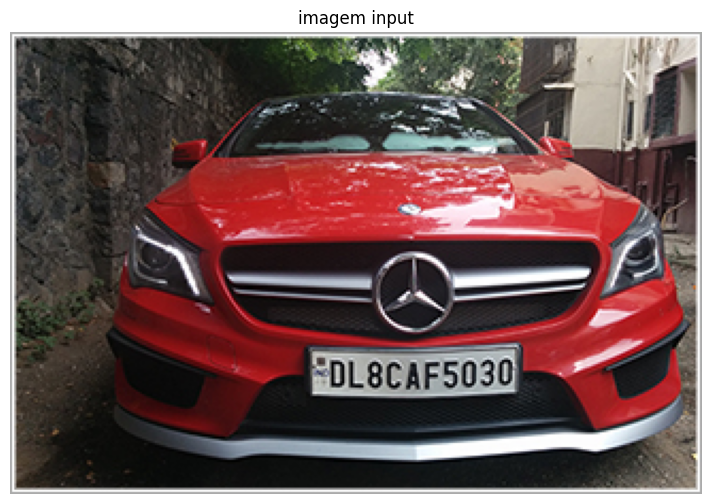

In [7]:
def display(img_, title=''):
    img = cv2.cvtColor(img_, cv2.COLOR_BGR2RGB)
    fig = plt.figure(figsize=(10,6))
    ax = plt.subplot(111)
    ax.imshow(img)
    plt.axis('off')
    plt.title(title)
    plt.show()

img = cv2.imread('drive/My Drive/license_plate/car.jpg')
display(img, 'imagem input')

In [8]:
# obtendo a placa a partir da imagem processada

output_img, plate = detect_plate(img)

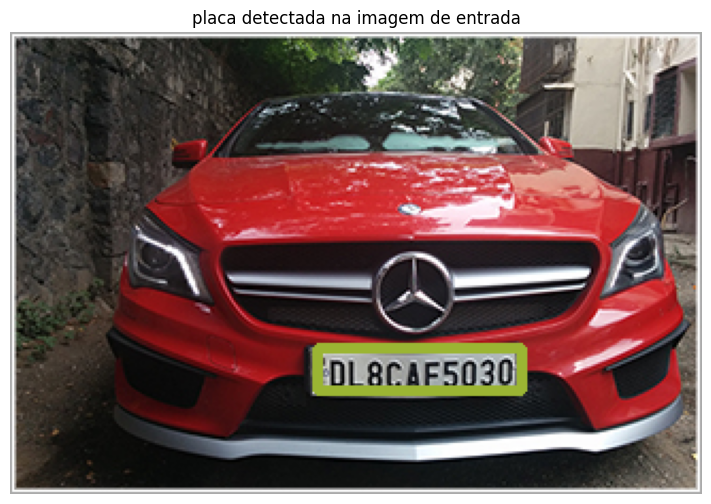

In [9]:
display(output_img, 'placa detectada na imagem de entrada')

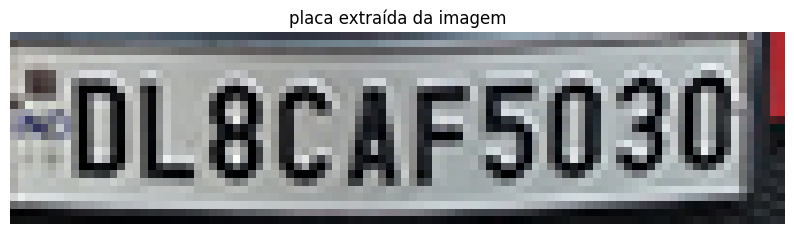

In [10]:
display(plate, 'placa extraída da imagem')

## 4. Segmentação de imagens (contorno - Vide Demo 4)

In [11]:
# combinando os contornos com a placa

def find_contours(dimensions, img) :

    # encontra os contornos na imagem
    cntrs, _ = cv2.findContours(img.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    # recuperando dimensões potenciais
    lower_width = dimensions[0]
    upper_width = dimensions[1]
    lower_height = dimensions[2]
    upper_height = dimensions[3]

    # verificando os maiores 5 ou 15 contornos da placa exemplo
    cntrs = sorted(cntrs, key=cv2.contourArea, reverse=True)[:15]

    ii = cv2.imread('contorno.jpg')

    x_cntr_list = []
    target_contours = []
    img_res = []
    for cntr in cntrs :
        # detecta o contorno na imagem binária e retorna as coordenadas do retângulo que o envolve
        intX, intY, intWidth, intHeight = cv2.boundingRect(cntr)

        # verificando as dimensões do contorno para filtrar os caracteres pelo tamanho do contorno
        if intWidth > lower_width and intWidth < upper_width and intHeight > lower_height and intHeight < upper_height :
            x_cntr_list.append(intX) #armazena a coordenada x do contorno do caractere, para ser usada posteriormente na indexação dos contornos

            char_copy = np.zeros((44,24))
            # extraindo cada caractere usando as coordenadas do retângulo delimitador.
            char = img[intY:intY+intHeight, intX:intX+intWidth]
            char = cv2.resize(char, (20, 40))

            cv2.rectangle(ii, (intX,intY), (intWidth+intX, intY+intHeight), (50,21,200), 2)
            plt.imshow(ii, cmap='gray')

            # torna o resultado formatado para classificação: inverte as cores
            char = cv2.subtract(255, char)

            # redimensionando a imagem para 24x44 com borda preta
            char_copy[2:42, 2:22] = char
            char_copy[0:2, :] = 0
            char_copy[:, 0:2] = 0
            char_copy[42:44, :] = 0
            char_copy[:, 22:24] = 0

            img_res.append(char_copy) # lista que armazena a imagem binária da placa (ainda não classificada)

    # retorna os caracteres em ordem crescente em relação à coordenada x (caractere mais à esquerda primeiro)

    plt.show()

    # função arbitrária que armazena lista ordenada de índices de caracteres

    indices = sorted(range(len(x_cntr_list)), key=lambda k: x_cntr_list[k])
    img_res_copy = []
    for idx in indices:
        img_res_copy.append(img_res[idx]) # armazena imagens das placas de acordo com seu índice
    img_res = np.array(img_res_copy)

    return img_res

In [12]:
# encontrando caracteres nas imagens resultantes

def segment_characters(image) :

    # pré-processamento de imagem de placa recortada

    img_lp = cv2.resize(image, (333, 75))
    img_gray_lp = cv2.cvtColor(img_lp, cv2.COLOR_BGR2GRAY)
    _, img_binary_lp = cv2.threshold(img_gray_lp, 200, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    img_binary_lp = cv2.erode(img_binary_lp, (3,3))
    img_binary_lp = cv2.dilate(img_binary_lp, (3,3))

    LP_WIDTH = img_binary_lp.shape[0]
    LP_HEIGHT = img_binary_lp.shape[1]

    # deixa as bordas brancas

    img_binary_lp[0:3,:] = 255
    img_binary_lp[:,0:3] = 255
    img_binary_lp[72:75,:] = 255
    img_binary_lp[:,330:333] = 255

    # estimativas de tamanhos de contornos de caracteres das placas "cortadas"

    dimensions = [LP_WIDTH/6,
                       LP_WIDTH/2,
                       LP_HEIGHT/10,
                       2*LP_HEIGHT/3]
    plt.imshow(img_binary_lp, cmap='gray')
    plt.show()
    cv2.imwrite('contorno.jpg',img_binary_lp)

    # obtendo contornos dentro da placa "cortada"

    char_list = find_contours(dimensions, img_binary_lp)

    return char_list

## 5. Caracteres Segmentados

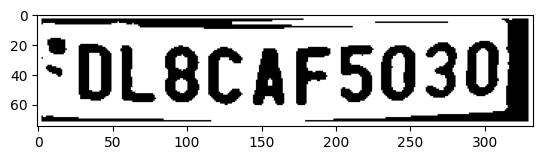

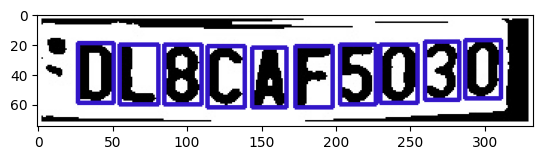

In [13]:
char = segment_characters(plate)

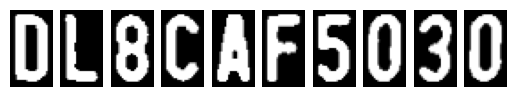

In [14]:
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(char[i], cmap='gray')
    plt.axis('off')

In [15]:
train_datagen = ImageDataGenerator(rescale=1./255, width_shift_range=0.1, height_shift_range=0.1)
path = 'drive/My Drive/license_plate/data'
train_generator = train_datagen.flow_from_directory(
        path+'/train',  # diretório de destino - imagens treinamento
        target_size=(28,28),  # todas as imagens serão redimensionadas para 28x28
        batch_size=1,
        class_mode='sparse',
        color_mode='rgb')

validation_generator = train_datagen.flow_from_directory(
        path+'/val',  # diretório de destino - imagens validação
        target_size=(28,28),  # # todas as imagens serão redimensionadas para 28x28 com batch_size=1,
        class_mode='sparse',
        color_mode='rgb')

Found 864 images belonging to 36 classes.
Found 216 images belonging to 36 classes.


In [16]:
# métricas para verificar o desempenho do modelo durante o treinamento

def f1score(y_true, y_pred):
  return f1_score(y_true, tf.math.argmax(y_pred, axis=1), average='micro')

def custom_f1score(y, y_pred):
  f1 = tf.py_function(f1score, (y, y_pred), [tf.float32]) # Alterado para tf.float32
  f1 = f1[0] # Extrair o tensor da lista
  f1.set_shape([]) # Explicitly set shape to scalar
  return f1

## 6. Construção da Rede Neural Convolucional

In [17]:
model = Sequential()
model.add(Conv2D(16, (22,22), input_shape=(28, 28, 3), activation='relu', padding='same'))
model.add(Conv2D(32, (16,16), input_shape=(28, 28, 3), activation='relu', padding='same'))
model.add(Conv2D(64, (8,8), input_shape=(28, 28, 3), activation='relu', padding='same'))
model.add(Conv2D(64, (4,4), input_shape=(28, 28, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(4, 4)))
model.add(Dropout(0.4))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(36, activation='softmax'))

model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizers.Adam(learning_rate=0.0001), metrics=[custom_f1score])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │        23,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │       131,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 36)             │         4,644 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 757,268 (2.89 MB)

 Trainable params: 757,268 (2.89 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
class stop_training_callback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs={}):
    if(logs.get('val_custom_f1score') > 0.99):
      self.model.stop_training = True

In [20]:
batch_size = 1
callbacks = [stop_training_callback()]
model.fit(
      train_generator,
      steps_per_epoch = train_generator.samples // batch_size,
      validation_data = validation_generator,
      epochs = 5, verbose=1, callbacks=callbacks)

Epoch 1/5
864/864 ━━━━━━━━━━━━━━━━━━━━ 311s 358ms/step - custom_f1score: 0.1250 - loss: 3.2007 - val_custom_f1score: 0.3095 - val_loss: 2.5653
Epoch 2/5
864/864 ━━━━━━━━━━━━━━━━━━━━ 84s 97ms/step - custom_f1score: 0.5556 - loss: 1.4938 - val_custom_f1score: 0.7545 - val_loss: 0.9432
Epoch 3/5
864/864 ━━━━━━━━━━━━━━━━━━━━ 85s 98ms/step - custom_f1score: 0.7523 - loss: 0.7619 - val_custom_f1score: 0.7798 - val_loss: 0.6605
Epoch 4/5
864/864 ━━━━━━━━━━━━━━━━━━━━ 87s 101ms/step - custom_f1score: 0.8484 - loss: 0.4823 - val_custom_f1score: 0.9375 - val_loss: 0.2230
Epoch 5/5
864/864 ━━━━━━━━━━━━━━━━━━━━ 85s 98ms/step - custom_f1score: 0.8889 - loss: 0.3720 - val_custom_f1score: 0.9241 - val_loss: 0.2175


In [21]:
# prevendo a saída

def fix_dimension(img):
  new_img = np.zeros((28,28,3))
  for i in range(3):
    new_img[:,:,i] = img
  return new_img

def show_results():
    dic = {}
    characters = '0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ'
    for i,c in enumerate(characters):
        dic[i] = c

    output = []
    for i,ch in enumerate(char): #iterando sobre os carcateres
        img_ = cv2.resize(ch, (28,28), interpolation=cv2.INTER_AREA)
        img = fix_dimension(img_)
        img = img.reshape(1,28,28,3) #preparando imagem para o modelo
        y_ = np.argmax(model.predict(img), axis=1)[0] # predição da classe
        character = dic[y_] #
        output.append(character) #armazenando o resultado em uma lista

    plate_number = ''.join(output)

    return plate_number

print(show_results())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
0L8CAF5030


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━

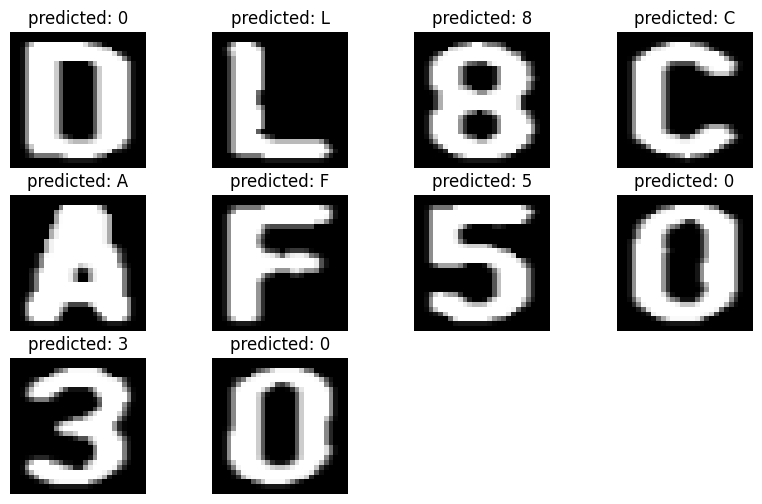

In [22]:
# caracteres segmentados e seu valor previsto.

plt.figure(figsize=(10,6))
for i,ch in enumerate(char):
    img = cv2.resize(ch, (28,28), interpolation=cv2.INTER_AREA)
    plt.subplot(3,4,i+1)
    plt.imshow(img,cmap='gray')
    plt.title(f'predicted: {show_results()[i]}')
    plt.axis('off')
plt.show()